In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diamonds-databcn0423/train.csv
/kaggle/input/diamonds-databcn0423/test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
test = pd.read_csv('/kaggle/input/diamonds-databcn0423/test.csv')
test.head()

,id,carat,cut,color,clarity,depth,table,x,y,z
0,0,0.81,Ideal,F,SI1,61.5,57.0,6.01,6.06,3.71
1,1,0.50,Fair,F,I1,63.8,58.0,5.08,4.97,3.21
2,2,0.31,Ideal,D,VVS2,60.1,56.0,4.43,4.46,2.67
3,3,1.52,Fair,I,SI2,64.7,58.0,7.19,7.22,4.66
4,4,0.35,Premium,D,VVS1,60.8,58.0,4.55,4.53,2.76


In [4]:
train = pd.read_csv('/kaggle/input/diamonds-databcn0423/train.csv')
train.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928
1,1,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477
2,2,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810
3,3,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824
4,4,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776


In [5]:
combined = pd.concat([train,test])
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928
1,1,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477
2,2,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810
3,3,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824
4,4,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776


In [6]:
combined.infer_objects()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928
1,1,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477
2,2,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810
3,3,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824
4,4,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776
...,...,...,...,...,...,...,...,...,...,...,...
13480,13480,0.52,Ideal,D,VVS2,61.4,56.0,5.23,5.20,3.20,NaN
13481,13481,1.01,Very Good,E,VS2,59.3,59.0,6.50,6.56,3.87,NaN
13482,13482,1.50,Premium,H,VS2,60.6,61.0,7.34,7.31,4.44,NaN
13483,13483,0.40,Ideal,E,VVS2,62.5,54.0,4.75,4.76,2.97,NaN


In [7]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53940 entries, 0 to 13484
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   depth    53940 non-null  float64
 6   table    53940 non-null  float64
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
 10  price    40455 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 4.9+ MB


In [8]:
combined.dtypes

id           int64
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price      float64
dtype: object

In [9]:
combined.isnull().sum()/len(combined)*100

id          0.0
carat       0.0
cut         0.0
color       0.0
clarity     0.0
depth       0.0
table       0.0
x           0.0
y           0.0
z           0.0
price      25.0
dtype: float64

In [10]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,53940.0,16855.750000,11839.550649,0.000,6742.000,13484.500,26969.250,40454.000
carat,53940.0,0.797940,0.474011,0.200,0.400,0.700,1.040,5.010
depth,53940.0,61.749405,1.432621,43.000,61.000,61.800,62.500,79.000
table,53940.0,57.457184,2.234491,43.000,56.000,57.000,59.000,95.000
x,53940.0,5.731157,1.121761,0.000,4.710,5.700,6.540,10.740
y,53940.0,5.734526,1.142135,0.000,4.720,5.710,6.540,58.900
z,53940.0,3.538734,0.705699,0.000,2.910,3.530,4.040,31.800
price,40455.0,7.785115,1.014267,5.787,6.851,7.782,8.578,9.843


In [11]:
combined.shape

(53940, 11)

In [12]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR= Q3-Q1
print(IQR)

id       20227.250
carat        0.640
depth        1.500
table        3.000
x            1.830
y            1.820
z            1.130
price        1.727
dtype: float64


/tmp/ipykernel_20/2108988077.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_20/2108988077.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_20/2108988077.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [13]:
combined.kurt()

/tmp/ipykernel_20/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


id       -1.105324
carat     1.256635
depth     5.739415
table     2.801857
x        -0.618161
y        91.214557
z        47.086619
price    -1.100617
dtype: float64

In [14]:
combined.skew()

/tmp/ipykernel_20/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


id       0.415589
carat    1.116646
depth   -0.082294
table    0.796896
x        0.378676
y        2.434167
z        1.522423
price    0.119199
dtype: float64

<Axes: >

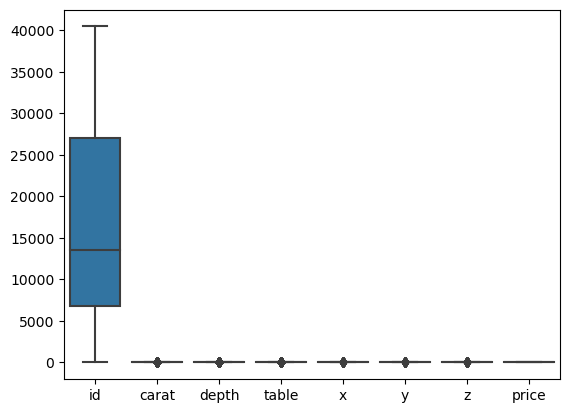

In [15]:
sns.boxplot(combined)

<Axes: >

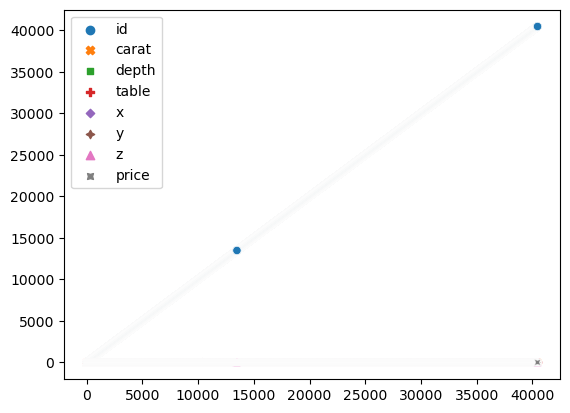

In [16]:
sns.scatterplot(combined)

<Axes: >

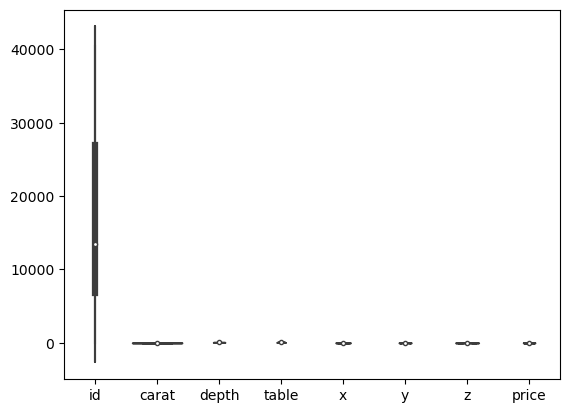

In [17]:
sns.violinplot(combined)

<Axes: >

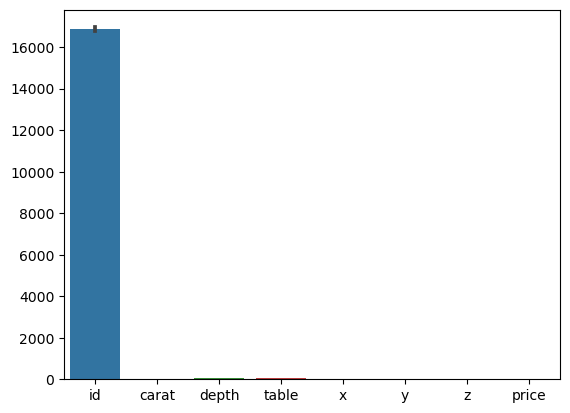

In [18]:
sns.barplot(combined)

<Axes: ylabel='Density'>

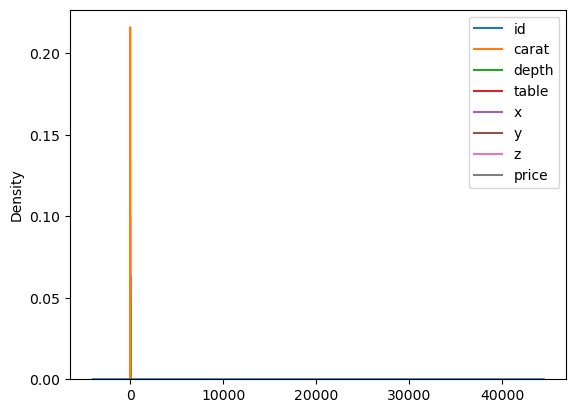

In [19]:
sns.kdeplot(combined)

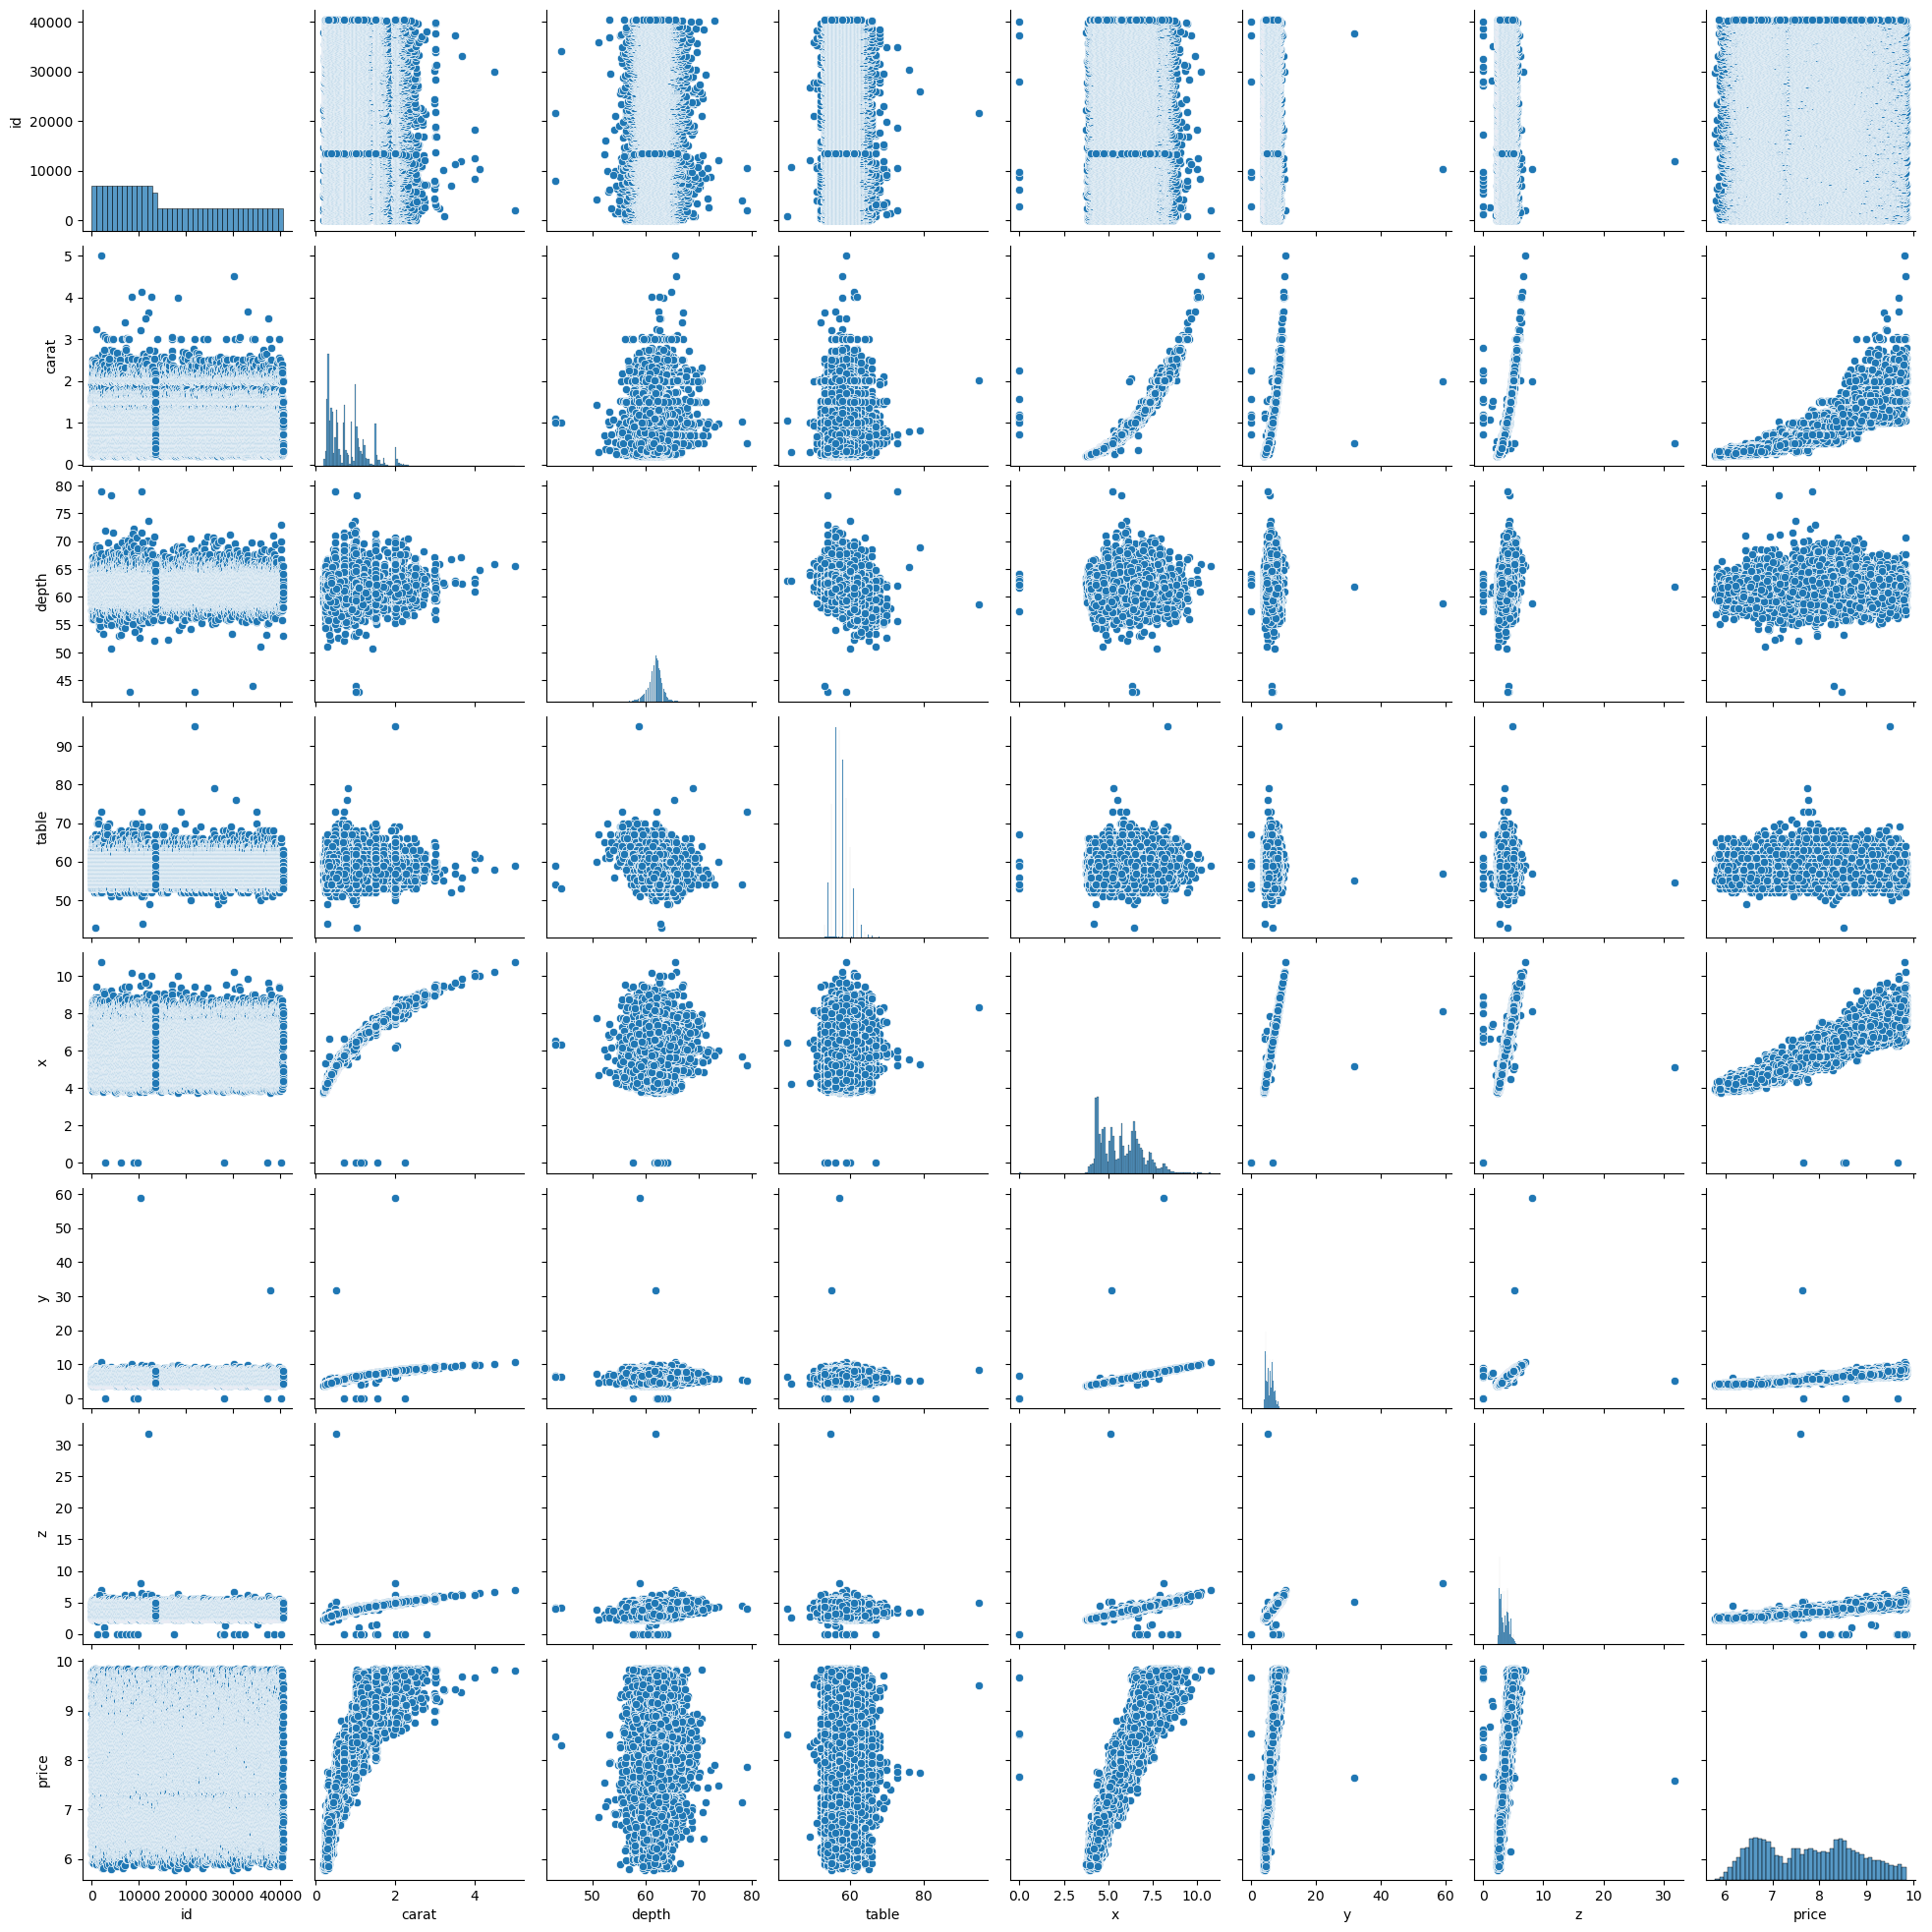

In [20]:
sns.pairplot(combined)

/tmp/ipykernel_20/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

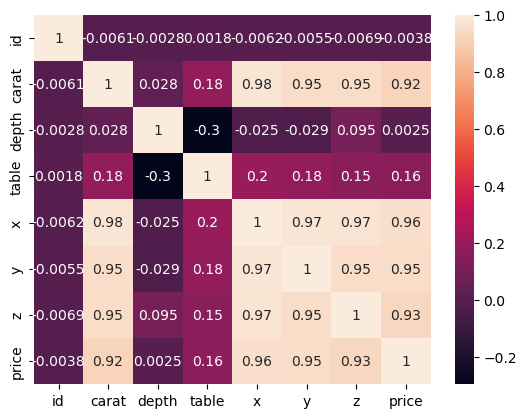

In [21]:
sns.heatmap(combined.corr(),annot=True)

In [22]:
combined['id']=combined['id'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_20/401063577.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')


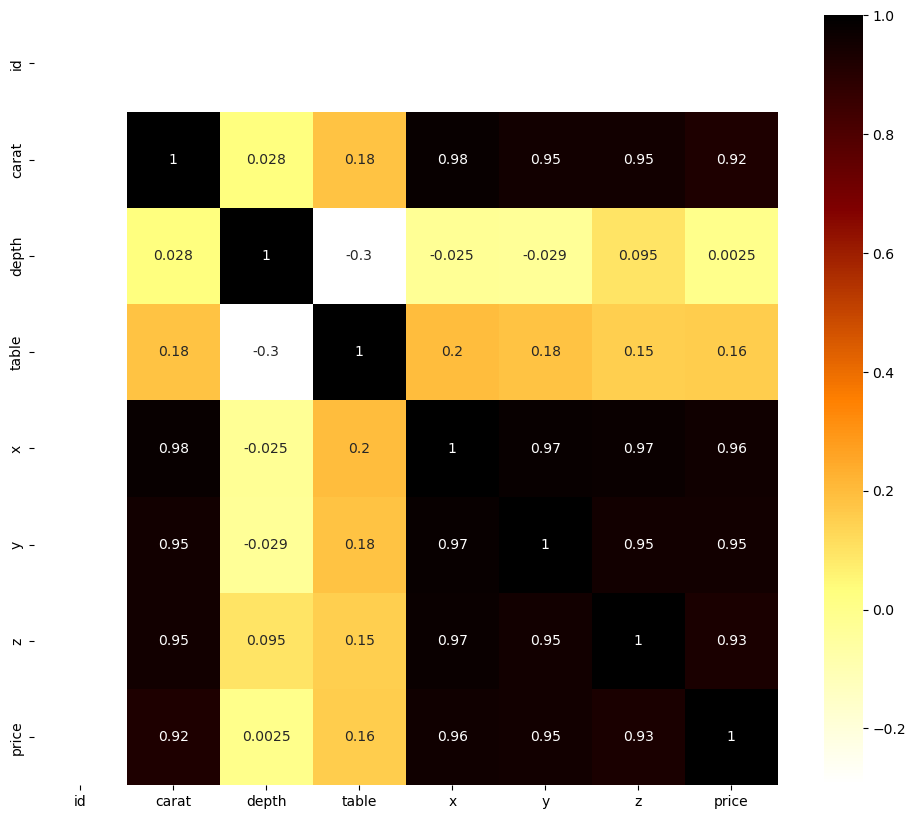

In [23]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

In [24]:
cat_cols = combined.select_dtypes(include='object')

In [25]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: cut, dtype: int64
__________________________________________________
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: color, dtype: int64
__________________________________________________
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: clarity, dtype: int64
__________________________________________________


In [26]:
num_cols = combined.select_dtypes(include='number')

In [27]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

id
Series([], Name: id, dtype: int64)
__________________________________________________
carat
0.30    2604
0.31    2249
1.01    2242
0.70    1981
0.32    1840
        ... 
3.22       1
3.11       1
3.02       1
5.01       1
3.51       1
Name: carat, Length: 273, dtype: int64
__________________________________________________
depth
62.0    2239
61.9    2163
61.8    2077
62.2    2039
62.1    2020
        ... 
73.6       1
54.6       1
52.7       1
54.3       1
53.8       1
Name: depth, Length: 184, dtype: int64
__________________________________________________
table
56.0    9881
57.0    9724
58.0    8369
59.0    6572
55.0    6268
        ... 
79.0       1
63.3       1
65.4       1
95.0       1
44.0       1
Name: table, Length: 127, dtype: int64
__________________________________________________
x
4.37     448
4.34     437
4.33     429
4.38     428
4.32     425
        ... 
9.05       1
9.38       1
8.89       1
9.54       1
10.02      1
Name: x, Length: 554, dtype: int64
______________

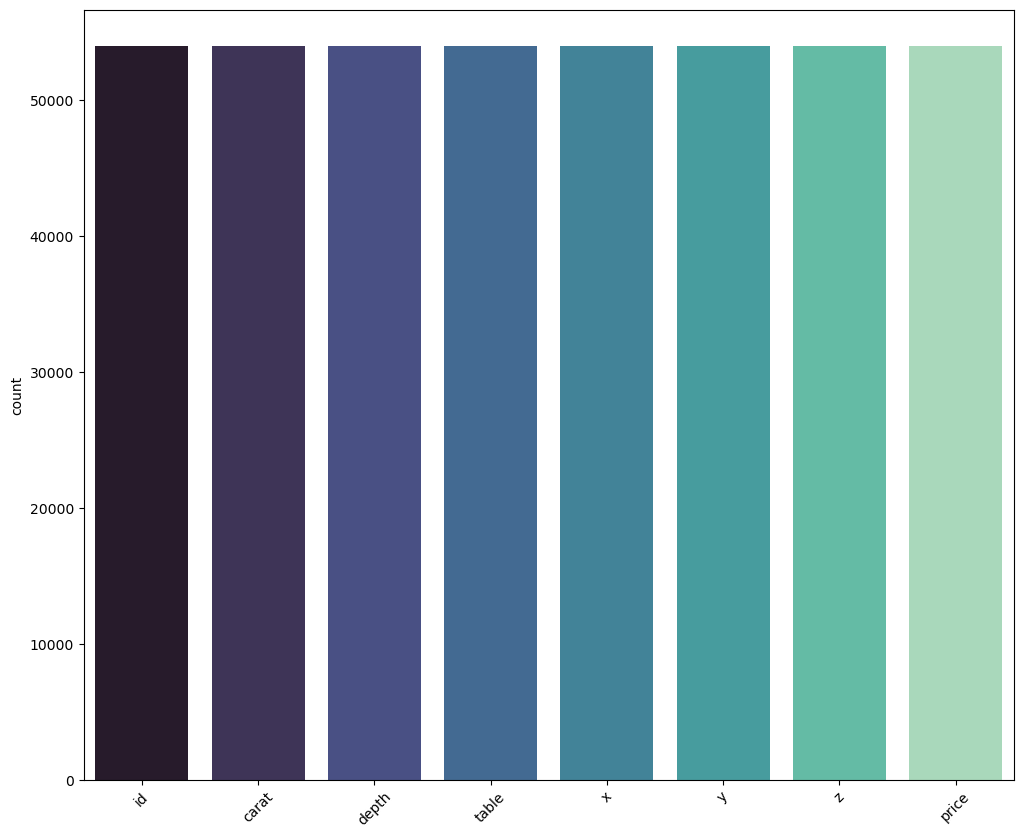

In [28]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

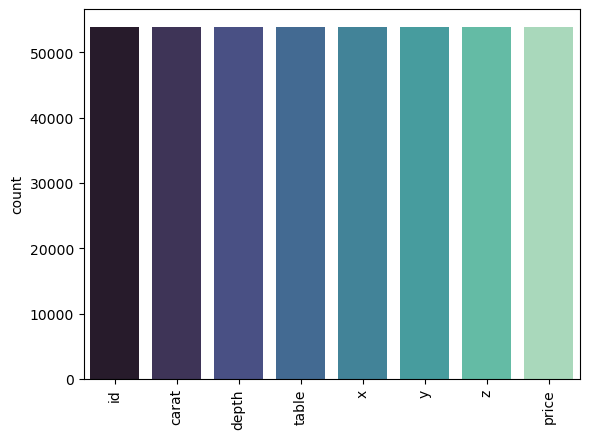

In [29]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'id'),
  Text(1, 0, 'carat'),
  Text(2, 0, 'depth'),
  Text(3, 0, 'table'),
  Text(4, 0, 'x'),
  Text(5, 0, 'y'),
  Text(6, 0, 'z'),
  Text(7, 0, 'price')])

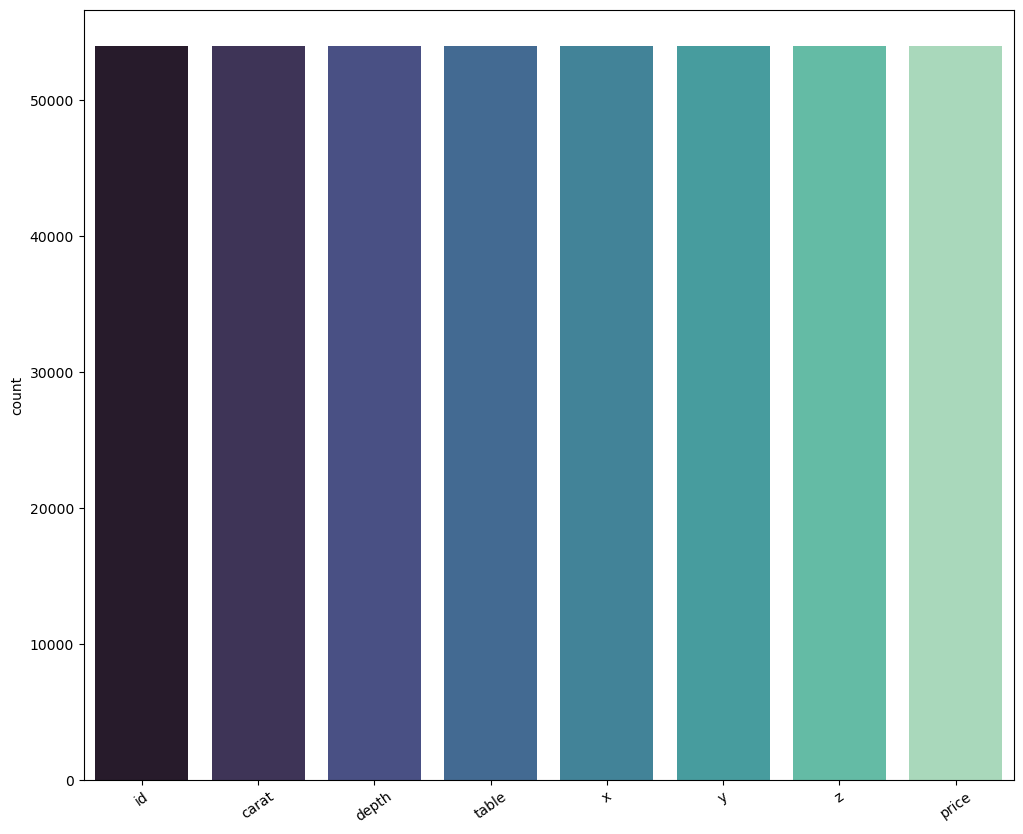

In [30]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=35)

In [31]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,NaN,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928
1,NaN,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477
2,NaN,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810
3,NaN,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824
4,NaN,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776


In [32]:

combined['id'].value_counts().index[1:]

Float64Index([], dtype='float64')

In [33]:
combined['id'].unique()

array([nan])

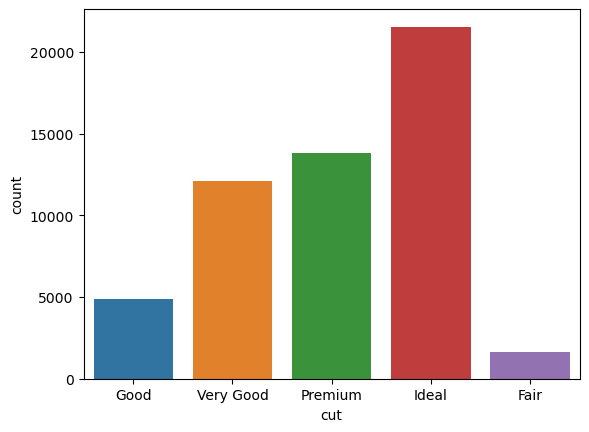

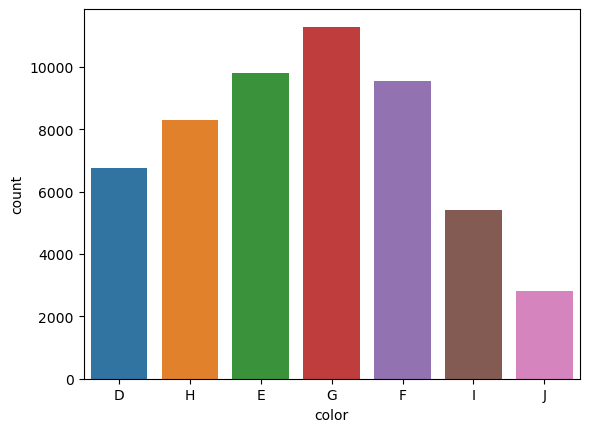

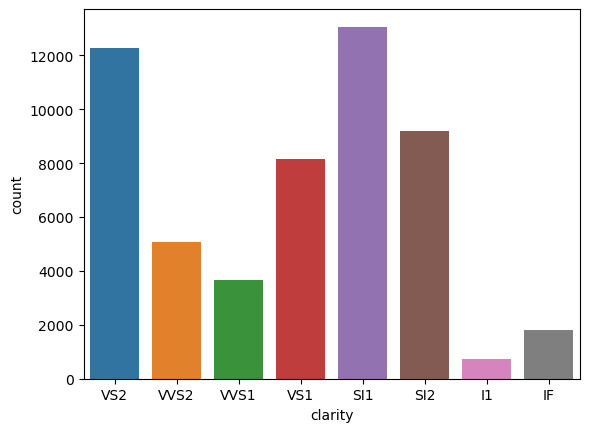

In [34]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

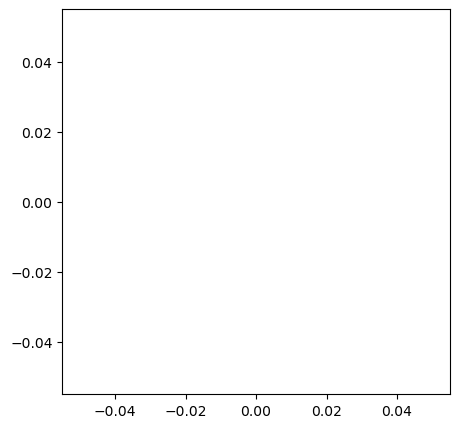

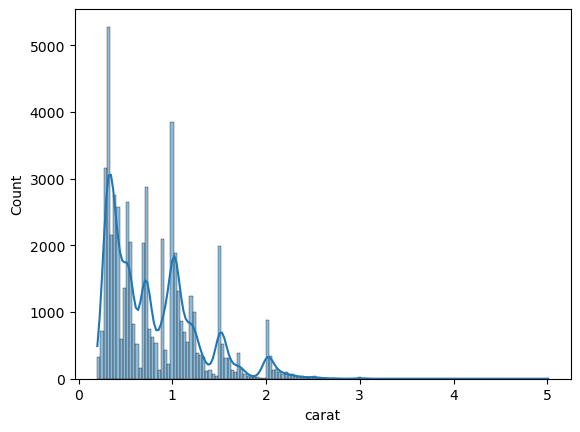

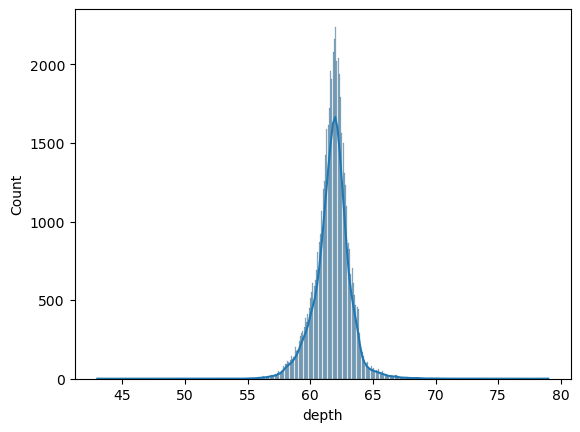

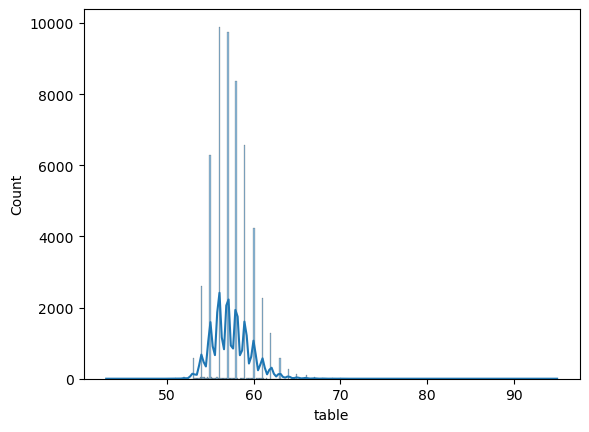

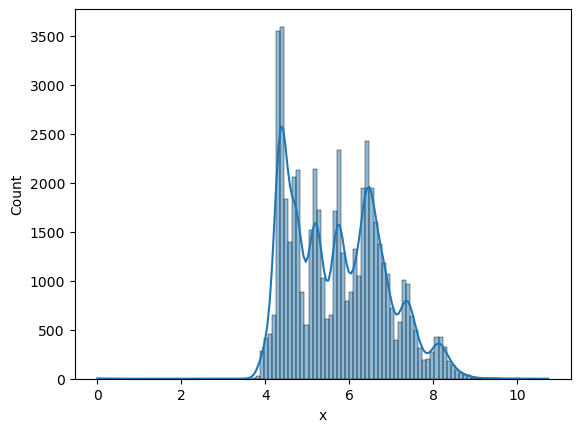

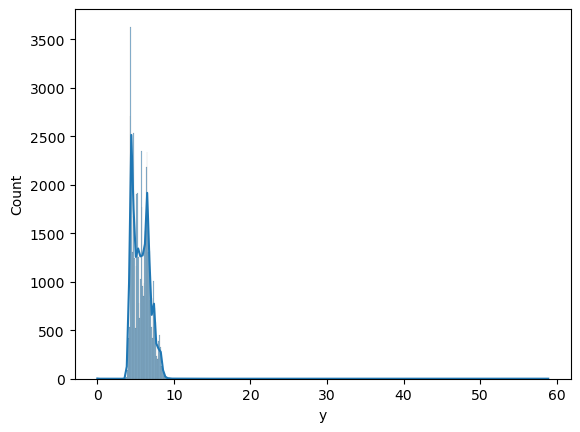

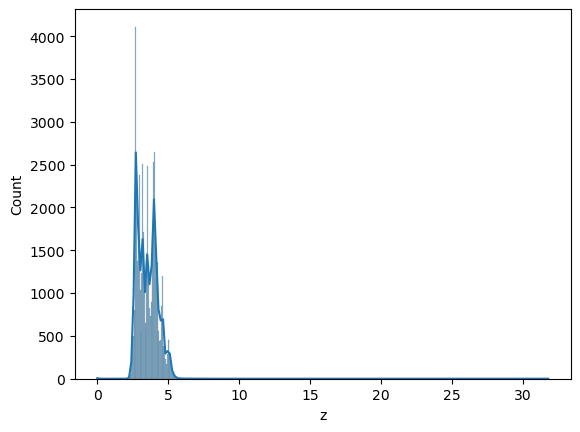

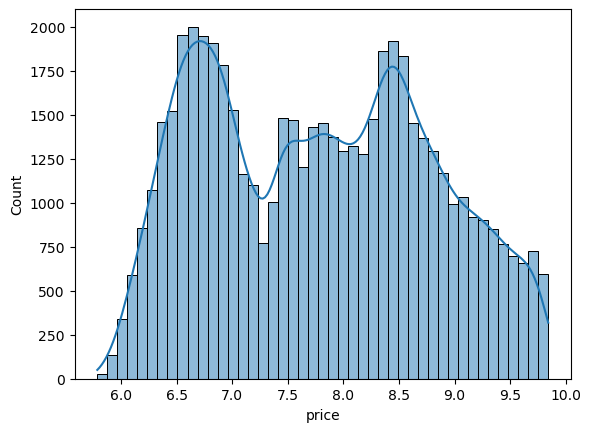

In [35]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

In [36]:
# Replacing weird values
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [37]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,NaN,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928
1,NaN,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477
2,NaN,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810
3,NaN,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824
4,NaN,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776


In [38]:
# Treating tyoe of carat
combined['carat'].value_counts().head(9).index[1:]

Float64Index([0.31, 1.01, 0.7, 0.32, 1.0, 0.9, 0.41, 0.4], dtype='float64')

In [39]:
# Rebuild type of carat columns
for i in combined['carat'].value_counts().head(9).index[2:]:
    combined[i]=combined['carat']

In [40]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,NaN,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,NaN,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,NaN,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,NaN,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,NaN,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [41]:
combined['carat'].unique()

array([1.02, 0.35, 0.31, 0.38, 1.64, 1.62, 0.9 , 1.1 , 0.33, 0.59, 1.05,
       0.3 , 0.71, 0.91, 1.52, 1.51, 0.24, 1.01, 1.24, 1.54, 0.39, 0.75,
       1.  , 0.76, 0.93, 0.32, 0.52, 1.5 , 2.01, 0.44, 0.23, 2.18, 1.22,
       0.56, 0.55, 0.82, 1.07, 0.4 , 0.5 , 1.08, 0.27, 0.74, 1.16, 0.41,
       0.43, 1.34, 1.12, 1.31, 1.04, 1.29, 1.7 , 0.57, 0.42, 0.51, 0.6 ,
       0.46, 0.79, 0.53, 0.25, 1.09, 1.17, 0.37, 0.26, 0.61, 1.74, 0.73,
       0.7 , 1.19, 0.92, 0.77, 1.27, 0.72, 1.53, 2.21, 0.8 , 1.26, 0.54,
       0.34, 0.58, 2.11, 1.23, 0.84, 2.  , 0.28, 0.99, 1.6 , 0.62, 1.03,
       1.32, 0.83, 0.81, 0.63, 1.59, 2.3 , 2.02, 0.66, 0.36, 1.2 , 0.29,
       2.17, 1.71, 0.85, 1.21, 1.33, 1.25, 1.55, 0.47, 1.13, 0.48, 2.51,
       0.64, 1.67, 1.06, 1.15, 0.87, 1.36, 1.58, 1.72, 1.28, 2.04, 1.14,
       1.45, 1.61, 0.78, 0.49, 2.05, 0.65, 1.11, 2.1 , 2.09, 2.42, 1.4 ,
       0.98, 1.39, 3.24, 0.96, 1.78, 1.56, 2.27, 1.38, 1.76, 0.95, 2.4 ,
       2.56, 2.06, 1.57, 1.18, 1.8 , 1.35, 2.08, 0.

In [42]:
combined['carat']=combined['carat'].astype(float)

In [43]:
extreme=combined[(combined['carat']>85)|(combined['carat']<0)].index

In [44]:
for i in extreme:
    combined.loc[i,'carat']=np.nan

In [45]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,NaN,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,NaN,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,NaN,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,NaN,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,NaN,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [46]:
mapping = combined.groupby('carat')['id'].mean().to_dict()

In [47]:
combined['id']=combined['carat'].map(mapping)

In [48]:
combined['id']=round(combined['id'],0)

In [49]:
combined['id']=combined['id'].astype(str)

In [50]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,nan,1.02,Good,D,VS2,63.2,58.0,6.36,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,nan,0.35,Very Good,H,VVS2,61.0,57.0,4.54,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,nan,0.31,Premium,H,VVS1,60.5,58.0,4.43,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,nan,0.38,Ideal,E,VS1,61.4,56.0,4.66,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,nan,1.64,Ideal,G,VVS2,61.8,56.0,7.59,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [51]:
combined.isnull().sum()

id             0
carat          0
cut            0
color          0
clarity        0
depth          0
table          0
x              0
y              0
z              0
price      13485
1.01           0
0.7            0
0.32           0
1.0            0
0.9            0
0.41           0
0.4            0
dtype: int64

In [52]:
# Treating null of depth
combined.groupby('id')['depth'].apply(lambda x:x.fillna(x.mode()[0]))

/tmp/ipykernel_20/3042548583.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  combined.groupby('id')['depth'].apply(lambda x:x.fillna(x.mode()[0]))


0        63.2
1        61.0
2        60.5
3        61.4
4        61.8
         ... 
13480    61.4
13481    59.3
13482    60.6
13483    62.5
13484    61.6
Name: depth, Length: 53940, dtype: float64

In [53]:
map1 = combined.groupby(['id'])['depth'].agg(pd.Series.mode).to_dict()

In [54]:
combined['depth']=combined['id'].map(map1)

In [55]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,nan,1.02,Good,D,VS2,62.0,58.0,6.36,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,nan,0.35,Very Good,H,VVS2,62.0,57.0,4.54,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,nan,0.31,Premium,H,VVS1,62.0,58.0,4.43,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,nan,0.38,Ideal,E,VS1,62.0,56.0,4.66,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,nan,1.64,Ideal,G,VVS2,62.0,56.0,7.59,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [56]:
# treating null of table
combined['table'].isnull().sum()

0

In [57]:
map2 = combined.groupby(['id'])['table'].mean().to_dict()

In [58]:
combined['table']=combined['id'].map(map2)

In [59]:
combined['table']=combined['id'].map(map2)

In [60]:
combined['table'].isnull().sum()

0

In [61]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,nan,1.02,Good,D,VS2,62.0,57.457184,6.36,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,nan,0.35,Very Good,H,VVS2,62.0,57.457184,4.54,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,nan,0.31,Premium,H,VVS1,62.0,57.457184,4.43,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,nan,0.38,Ideal,E,VS1,62.0,57.457184,4.66,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,nan,1.64,Ideal,G,VVS2,62.0,57.457184,7.59,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [62]:
# treating null of x with help of id
combined['x']=combined['x'].astype(float)

In [63]:
map3 = combined.groupby('id')['x'].median().to_dict()

In [64]:
combined['x']=combined['id'].map(map3)

In [65]:
combined['x']=round(combined['x'],0)

In [66]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,nan,1.02,Good,D,VS2,62.0,57.457184,6.0,6.40,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,nan,0.35,Very Good,H,VVS2,62.0,57.457184,6.0,4.57,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,nan,0.31,Premium,H,VVS1,62.0,57.457184,6.0,4.40,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,nan,0.38,Ideal,E,VS1,62.0,57.457184,6.0,4.69,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,nan,1.64,Ideal,G,VVS2,62.0,57.457184,6.0,7.60,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [67]:
# Treating null of y wiht help of id
map4 = combined.groupby('id')['y'].agg(pd.Series.mode).to_dict()

In [68]:
combined['y']=combined['id'].map(map4)

In [69]:
combined['y'].dtypes

dtype('float64')

In [70]:
combined.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,1.01,0.7,0.32,1.0,0.9,0.41,0.4
0,nan,1.02,Good,D,VS2,62.0,57.457184,6.0,4.34,4.03,8.928,1.02,1.02,1.02,1.02,1.02,1.02,1.02
1,nan,0.35,Very Good,H,VVS2,62.0,57.457184,6.0,4.34,2.77,6.477,0.35,0.35,0.35,0.35,0.35,0.35,0.35
2,nan,0.31,Premium,H,VVS1,62.0,57.457184,6.0,4.34,2.67,6.810,0.31,0.31,0.31,0.31,0.31,0.31,0.31
3,nan,0.38,Ideal,E,VS1,62.0,57.457184,6.0,4.34,2.87,6.824,0.38,0.38,0.38,0.38,0.38,0.38,0.38
4,nan,1.64,Ideal,G,VVS2,62.0,57.457184,6.0,4.34,4.69,9.776,1.64,1.64,1.64,1.64,1.64,1.64,1.64


In [71]:
# Treating null of z with help of id
map5 = combined.groupby('id')['z'].mean().to_dict()

In [72]:
combined['z']=combined['id'].map(map5)

In [73]:
combined['z'].isnull().sum()

0

In [74]:
# treating null of price  with help of id
combined['price'].value_counts()

6.438    102
6.548     95
6.687     95
6.654     94
6.405     92
        ... 
6.303      1
7.690      1
7.189      1
6.016      1
5.866      1
Name: price, Length: 3512, dtype: int64

In [75]:
map5 = combined.groupby('id')['price'].agg(pd.Series.mode).to_dict()

In [76]:
combined['price']=combined['id'].map(map5)

In [77]:
cat_cols.shape,num_cols.shape

((53940, 3), (53940, 8))

In [78]:
combined.shape

(53940, 18)

In [79]:
combined['depth']=combined['depth'].map({True:1,False:0,np.nan:0})

In [80]:
combined['table']=combined['table'].map({True:1,False:0,np.nan:0})
combined['x']=combined['x'].map({True:1,False:0,np.nan:0})
combined['y']=combined['y'].map({True:1,False:0,np.nan:0})
combined['z']=combined['z'].map({True:1,False:0,np.nan:0})

In [81]:
  combined.isnull().sum()

id             0
carat          0
cut            0
color          0
clarity        0
depth      53940
table      53940
x          53940
y          53940
z          53940
price          0
1.01           0
0.7            0
0.32           0
1.0            0
0.9            0
0.41           0
0.4            0
dtype: int64

In [82]:
combined['z'].unique()

array([nan])

In [83]:
cat_cols

,cut,color,clarity
0,Good,D,VS2
1,Very Good,H,VVS2
2,Premium,H,VVS1
3,Ideal,E,VS1
4,Ideal,G,VVS2
...,...,...,...
13480,Ideal,D,VVS2
13481,Very Good,E,VS2
13482,Premium,H,VS2
13483,Ideal,E,VVS2


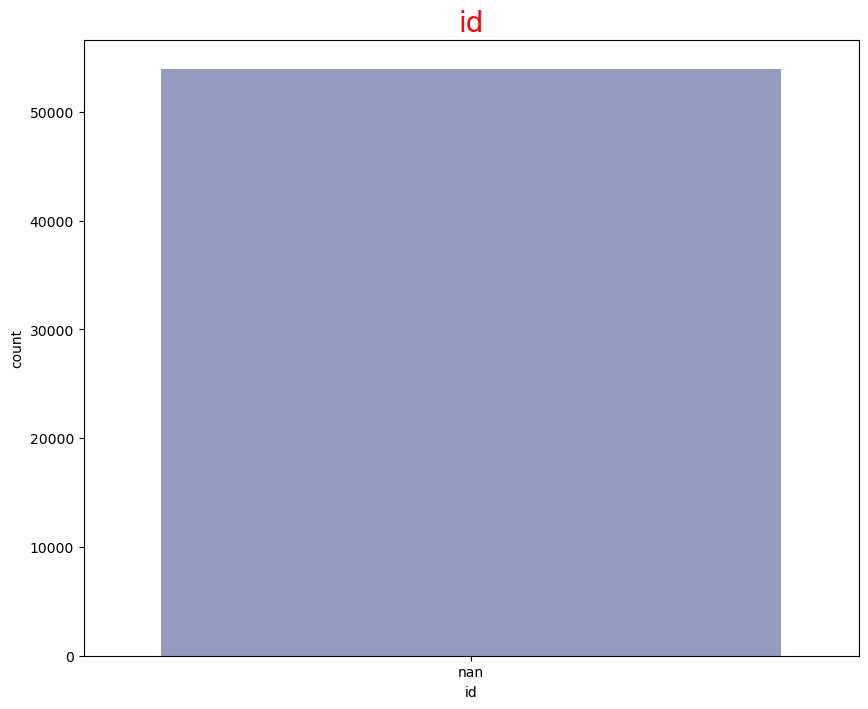

In [84]:
plt.figure(figsize=(10,8))
sns.countplot(data=combined,x='id',palette='BuPu_r')
plt.title('id',size=20,color="Red")
plt.show()


In [85]:
combined['id'].value_counts(normalize=True)*100

nan    100.0
Name: id, dtype: float64

In [86]:
train.shape[0]

40455

In [87]:
new_train=combined.iloc[0:train.shape[0],:]

In [88]:
new_test=combined.iloc[train.shape[0]:,:]

In [89]:
train.shape,new_train.shape,test.shape,new_test.shape

((40455, 11), (40455, 18), (13485, 10), (13485, 18))

In [90]:
import scipy.stats as stats


In [91]:
cat_cols = combined.select_dtypes(include='object')
num_cols = combined.select_dtypes(include='number')

In [92]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['id']==0,i]
    one=new_train.loc[new_train['id']==1,i]
    two=new_train.loc[new_train['id']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/_stats_py.py:3861: DegenerateDataWarning: at least one input has length 0
  warnings.warn(stats.DegenerateDataWarning('at least one input '


In [93]:
sig_cat=[]
for i in cat_cols:
    tb1=pd.crosstab(new_train[i],new_train['id'])
    tstat,pval,dof,freq=stats.chi2_contingency(tb1)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [94]:
train_new =new_train.loc[:,sig_cat+sig_num]

In [95]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [96]:
# Checking for multicollinearity

In [97]:
train_new

""
0
1
2
3
4
...
40450
40451
40452
40453


In [98]:
# Scaling the col
scaling = []

In [99]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [100]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [101]:
train_new

""
0
1
2
3
4
...
40450
40451
40452
40453


In [102]:
test_new

""
0
1
2
3
4
...
13480
13481
13482
13483
